In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
data = pd.read_csv('data/processed_data.csv')

## 1. Dataset Overview

In [3]:
# Data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18374 entries, 0 to 18373
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Type          18374 non-null  int64  
 1   New_building  18374 non-null  int64  
 2   nFloor        18374 non-null  int64  
 3   Floor         18374 non-null  int64  
 4   Height        18374 non-null  float64
 5   Sqm           18374 non-null  int64  
 6   Rooms         18374 non-null  int64  
 7   Bathrooms     18374 non-null  int64  
 8   Renovation    18374 non-null  float64
 9   Balcony       18374 non-null  int64  
 10  District      18374 non-null  object 
 11  Price_USD     18374 non-null  float64
dtypes: float64(3), int64(8), object(1)
memory usage: 1.7+ MB


In [29]:
# First few rows
data.head(10)

,Type,New_building,nFloor,Floor,Height,Sqm,Rooms,Bathrooms,Renovation,Balcony,Price_USD
0,1,0,9,6,2.80,68,2,1,2.0,0.0,95000.0
1,0,0,9,1,2.80,58,2,1,4.0,0.5,300000.0
2,2,1,12,6,3.00,46,2,1,2.0,1.0,87000.0
3,0,0,4,2,3.00,50,1,1,1.0,0.0,130000.0
4,0,0,5,1,2.75,70,3,1,2.0,2.0,145000.0
5,2,1,8,5,3.00,47,2,1,2.0,1.0,160000.0
6,0,0,5,2,3.00,65,2,1,3.0,1.0,137000.0
7,2,1,16,11,3.00,68,2,1,2.0,1.0,230000.0
8,0,0,5,3,2.75,36,1,1,1.0,0.0,65000.0
9,1,0,9,2,2.80,95,3,1,3.0,1.0,135000.0


In [30]:
# Display basic information
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
print(f"\nColumn Names:\n{list(data.columns)}")

Number of rows: 20879
Number of columns: 11

Column Names:
['Type', 'New_building', 'nFloor', 'Floor', 'Height', 'Sqm', 'Rooms', 'Bathrooms', 'Renovation', 'Balcony', 'Price_USD']


## 2. Statistical Summary

In [4]:
data.describe(include='all')

,Type,New_building,nFloor,Floor,Height,Sqm,Rooms,Bathrooms,Renovation,Balcony,District,Price_USD
count,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374,1.837400e+04
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Կենտրոն,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4722,NaN
mean,1.003810,0.309731,9.415805,5.551976,2.883292,76.410471,2.698487,1.238761,1.869680,1.437357,NaN,1.613118e+05
std,0.809234,0.462395,4.496685,3.704407,0.173254,24.642777,0.828045,0.446906,1.146549,1.009598,NaN,1.053261e+05
min,0.000000,0.000000,1.000000,1.000000,2.500000,13.000000,1.000000,1.000000,0.000000,0.000000,NaN,2.398800e+04
25%,0.000000,0.000000,5.000000,3.000000,2.750000,60.000000,2.000000,1.000000,1.000000,1.000000,NaN,9.700000e+04
50%,1.000000,0.000000,9.000000,5.000000,2.800000,75.000000,3.000000,1.000000,2.000000,2.000000,NaN,1.300000e+05
75%,2.000000,1.000000,14.000000,8.000000,3.000000,92.000000,3.000000,1.000000,3.000000,2.000000,NaN,1.890000e+05


## 3. Missing Values Analysis

In [39]:
# Check for missing values
missing_values = data.isnull().sum()
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
}).sort_values(by='Missing_Count', ascending=False)


if missing_df['Missing_Count'].sum() == 0:
    print("No missing values found in the dataset!")
else:
    print(missing_df[missing_df['Missing_Count'] > 0])

No missing values found in the dataset!


## 4. Target Variable Analysis (Price_USD)

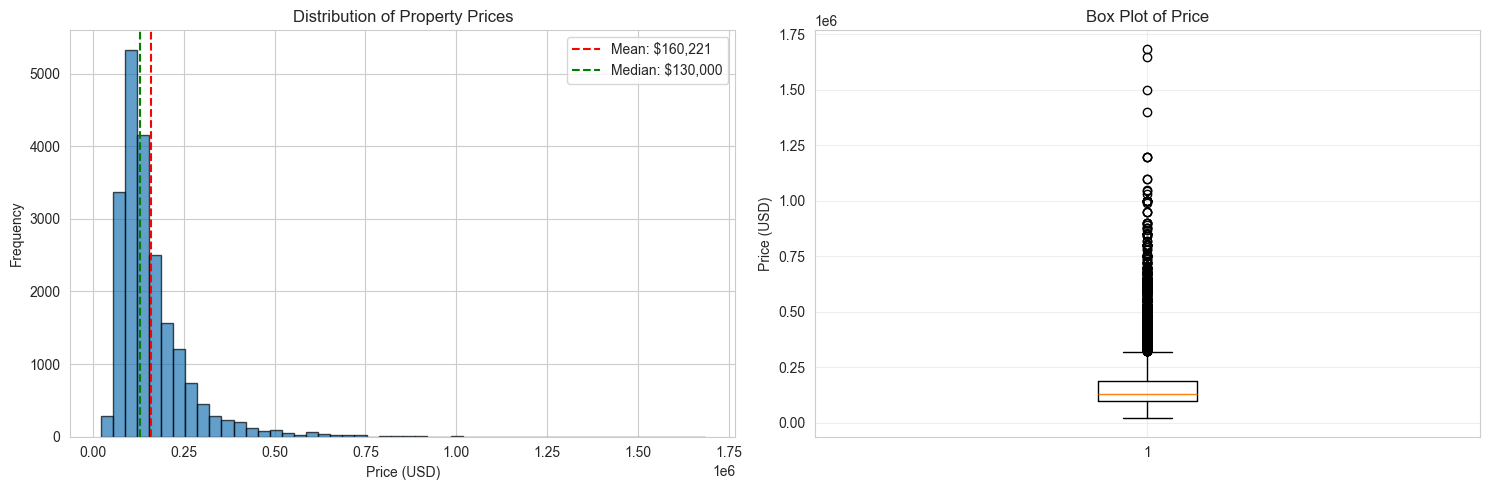

In [41]:
# Price distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(data['Price_USD'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Property Prices')
axes[0].axvline(data['Price_USD'].mean(), color='red', linestyle='--', label=f'Mean: ${data["Price_USD"].mean():,.0f}')
axes[0].axvline(data['Price_USD'].median(), color='green', linestyle='--', label=f'Median: ${data["Price_USD"].median():,.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(data['Price_USD'], vert=True)
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('Box Plot of Price')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Price distribution statistics
print("Price Statistics:")
print(f"Mean: ${data['Price_USD'].mean():,.2f}")
print(f"Median: ${data['Price_USD'].median():,.2f}")
print(f"Std Dev: ${data['Price_USD'].std():,.2f}")
print(f"Min: ${data['Price_USD'].min():,.2f}")
print(f"Max: ${data['Price_USD'].max():,.2f}")
print(f"Skewness: {data['Price_USD'].skew():.2f}")

Price Statistics:
Mean: $160,221.38
Median: $130,000.00
Std Dev: $103,415.24
Min: $21,000.00
Max: $1,685,000.00
Skewness: 3.16


## 5. Categorical Features Distribution

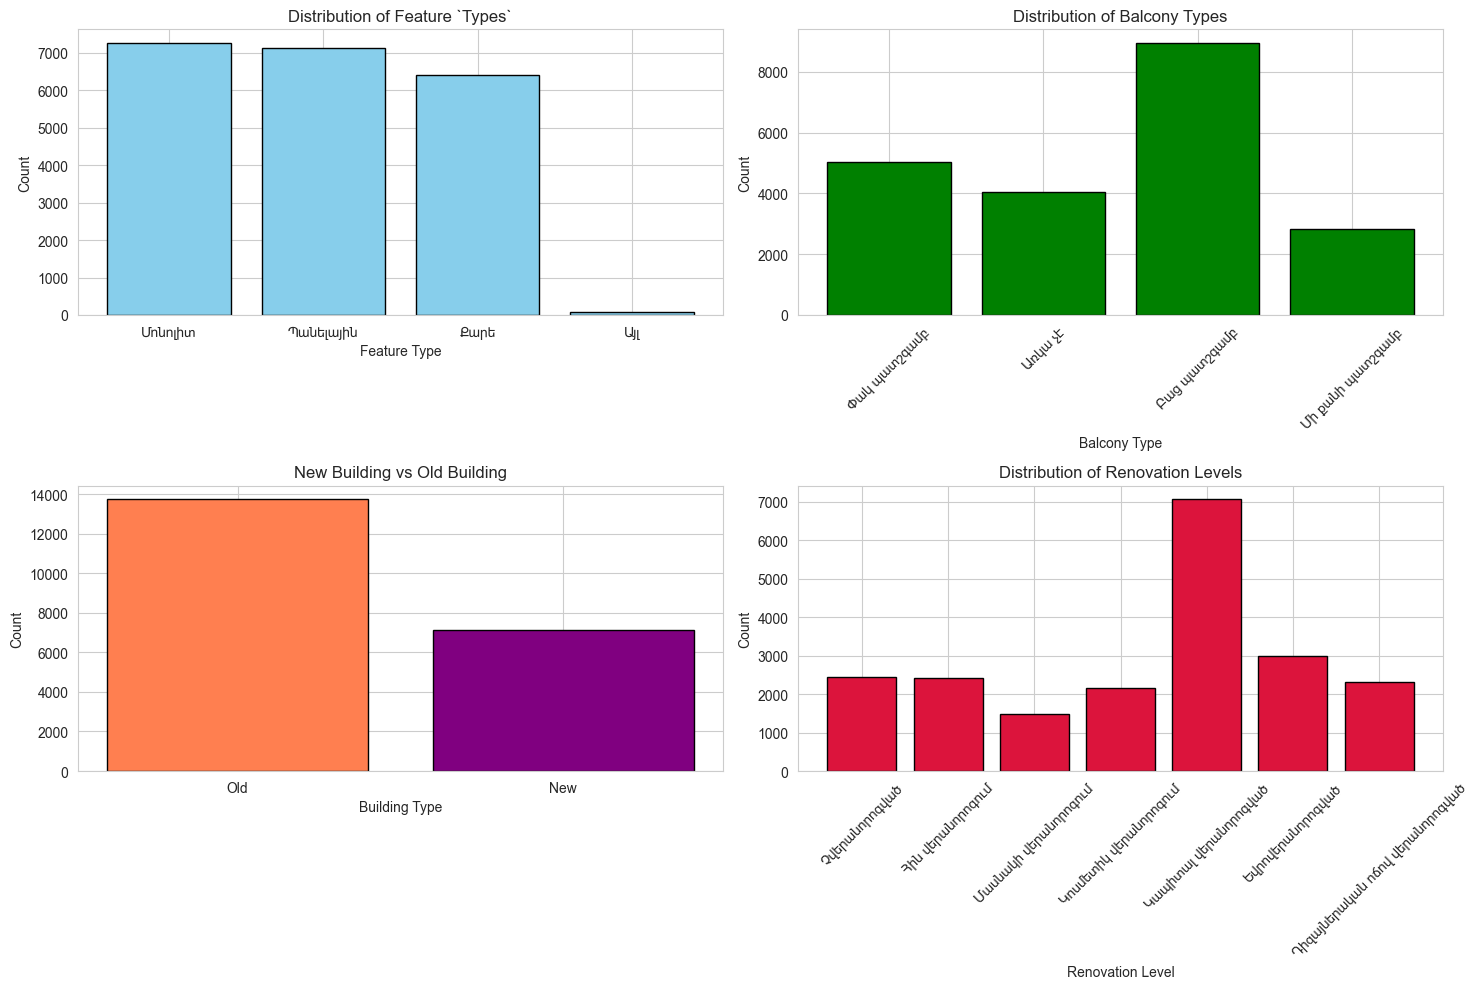

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Type
type_mapping = {0: 'Քարե', 1: 'Պանելային', 2: 'Մոնոլիտ', 3: 'Այլ'}
type_counts = data['Type'].value_counts()
type_labels = [type_mapping[key] for key in type_counts.index]
axes[0, 0].bar(type_labels, type_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Feature Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Feature `Types`')
axes[0, 0].set_xticks(type_counts.index)

# Balcony
balcony_counts = data['Balcony'].value_counts().sort_index()
balcony_ranking = {
    0: 'Փակ պատշգամբ', 
    0.5: 'Առկա չէ', 
    1: 'Բաց պատշգամբ', 
    2: 'Մի քանի պատշգամբ'
}
balcony_labels = [balcony_ranking[key] for key in balcony_counts.index]
axes[0, 1].bar(balcony_labels, balcony_counts.values, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Balcony Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Balcony Types')
axes[0, 1].tick_params(axis='x', rotation=45)

# New Building
new_building_counts = data['New_building'].value_counts()
axes[1, 0].bar(['Old', 'New'], new_building_counts.values, color=['coral', 'purple'], edgecolor='black')
axes[1, 0].set_xlabel('Building Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('New Building vs Old Building')


# Renovation
renovation_ranking = {
    0: 'Չվերանորոգված',
    0.5: 'Հին վերանորոգում',
    1: 'Մասնակի վերանորոգում',
    1.5: 'Կոսմետիկ վերանորոգում',
    2: 'Կապիտալ վերանորոգված',
    3: 'Եվրովերանորոգված',
    4: 'Դիզայներական ոճով վերանորոգված'
}
renovation_counts = data['Renovation'].value_counts().sort_index()
renovation_labels = [renovation_ranking[key] for key in renovation_counts.index]
axes[1, 1].bar(renovation_labels, renovation_counts.values, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Renovation Level')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distribution of Renovation Levels')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Numerical Features Distribution

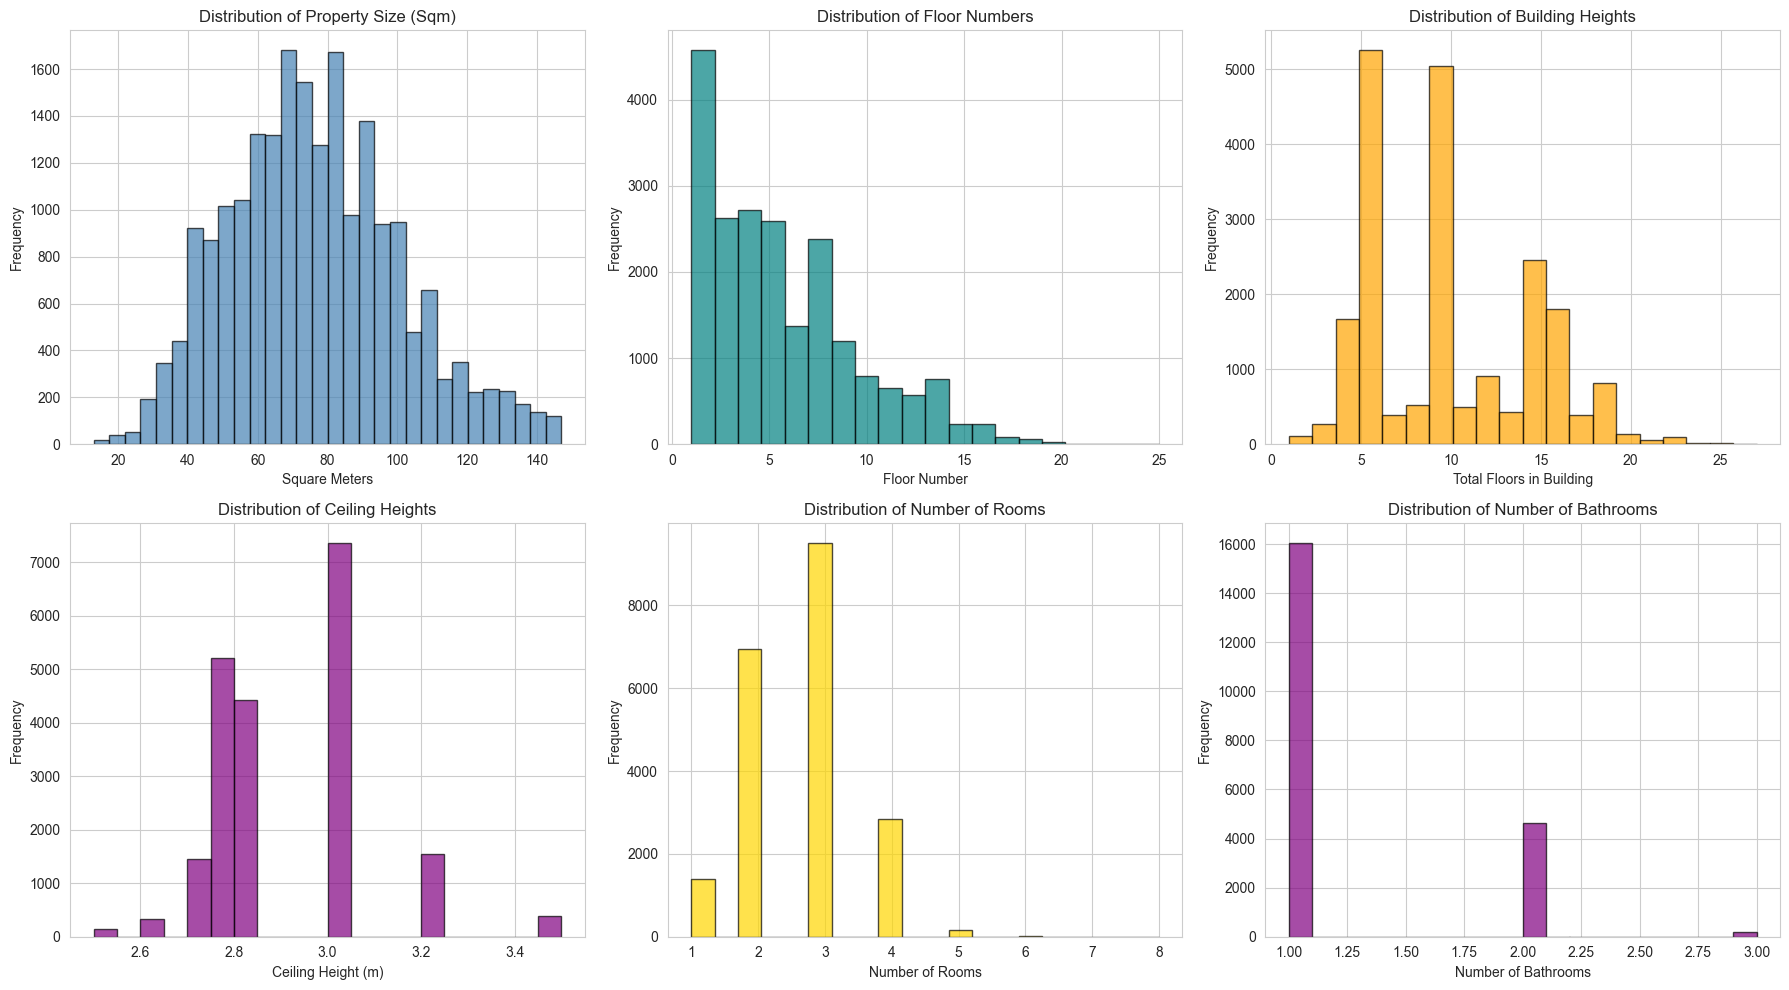

In [58]:
# Distribution of key numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Square meters
axes[0, 0].hist(data['Sqm'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Square Meters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Property Size (Sqm)')

# Floor
axes[0, 1].hist(data['Floor'], bins=20, color='teal', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Floor Number')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Floor Numbers')

# nFloor (Total floors in building)
axes[0, 2].hist(data['nFloor'], bins=20, color='orange', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Total Floors in Building')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Building Heights')

# Height (Ceiling height)
axes[1, 0].hist(data['Height'], bins=20, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Ceiling Height (m)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Ceiling Heights')

# Rooms
axes[1, 1].hist(data['Rooms'], bins=20, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Rooms')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Number of Rooms')

# Bathrooms
axes[1, 2].hist(data['Bathrooms'], bins=20, color='purple', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Number of Bathrooms')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Number of Bathrooms')


plt.tight_layout()
plt.show()

## 7. Price vs District

Price Statistics by District:

                           mean    median  count
District                                        
Կենտրոն           250905.676197  218000.0   4722
Նորք-Մարաշ        177374.839623  151500.0    106
Արաբկիր           163542.910177  148000.0   4019
Դավթաշեն          144745.079380  135000.0   1033
Քանաքեռ-Զեյթուն   140545.821689  121000.0   1374
Մալաթիա-Սեբաստիա  111525.695097  102000.0   1958
Ավան              109392.158192  103000.0    531
Աջափնյակ          108864.561732  100000.0   1547
Շենգավիթ          107068.294627   98000.0   1154
Նուբարաշեն        106443.218750   82500.0     32
Էրեբունի          104457.034274  100000.0    496
Նոր Նորք           97583.425820   89000.0   1402



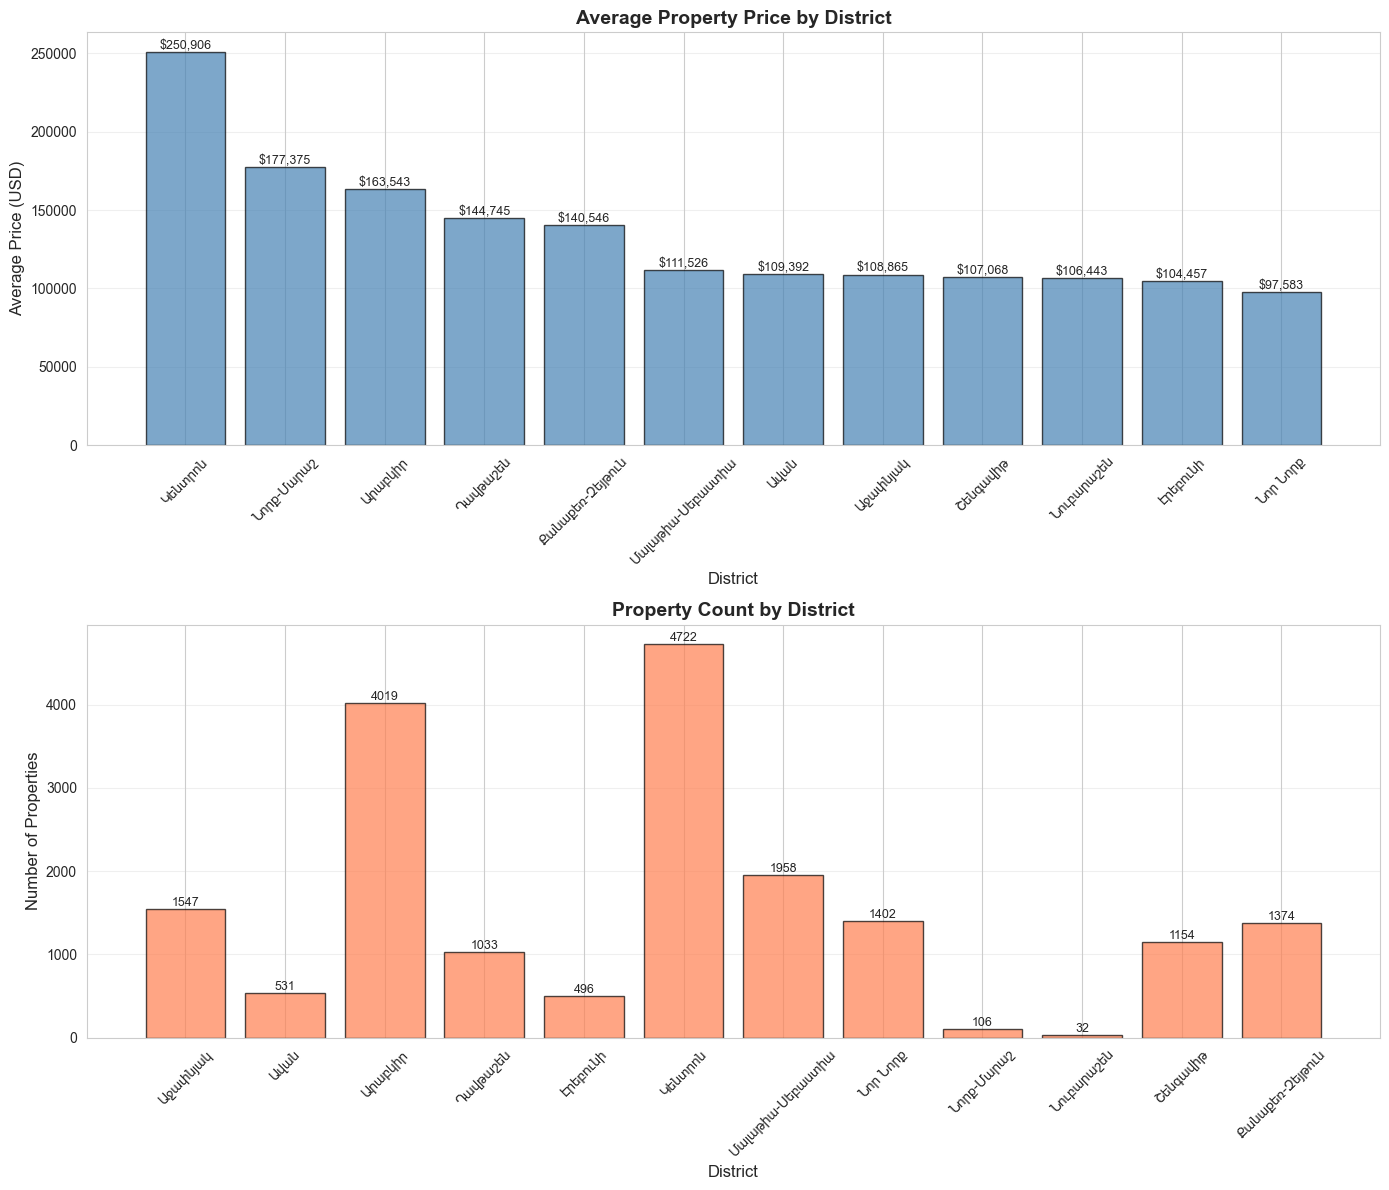

In [5]:
# Average price by district
district_price_stats = data.groupby('District')['Price_USD'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print("Price Statistics by District:\n")
print(district_price_stats)
print("\n" + "="*70)

# Visualize average price by district
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Bar chart - Average Price by District
axes[0].bar(district_price_stats.index, district_price_stats['mean'], 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('District', fontsize=12)
axes[0].set_ylabel('Average Price (USD)', fontsize=12)
axes[0].set_title('Average Property Price by District', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (district, row) in enumerate(district_price_stats.iterrows()):
    axes[0].text(i, row['mean'], f'${row["mean"]:,.0f}', 
                ha='center', va='bottom', fontsize=9)

# Bar chart - Number of Properties by District
district_counts = data['District'].value_counts().sort_index()
axes[1].bar(district_counts.index, district_counts.values, 
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('District', fontsize=12)
axes[1].set_ylabel('Number of Properties', fontsize=12)
axes[1].set_title('Property Count by District', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (district, count) in enumerate(district_counts.items()):
    axes[1].text(i, count, f'{count}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Box plot - Price distribution by district
plt.figure(figsize=(16, 8))
data.boxplot(column='Price_USD', by='District', figsize=(16, 8))
plt.xlabel('District', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.title('Price Distribution by District', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Violin plot - Alternative visualization showing price distribution
plt.figure(figsize=(16, 8))
districts_sorted = district_price_stats.index.tolist()
sns.violinplot(data=data, x='District', y='Price_USD', order=districts_sorted, palette='Set2')
plt.xlabel('District', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.title('Price Distribution by District (Violin Plot)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Correlation with Price_USD:

Price_USD       1.000000
Sqm             0.576073
Height          0.406432
Bathrooms       0.394531
New_building    0.344543
Rooms           0.333613
Balcony         0.239571
Type            0.209335
Renovation      0.191939
nFloor          0.143913
Floor           0.122426
Name: Price_USD, dtype: float64


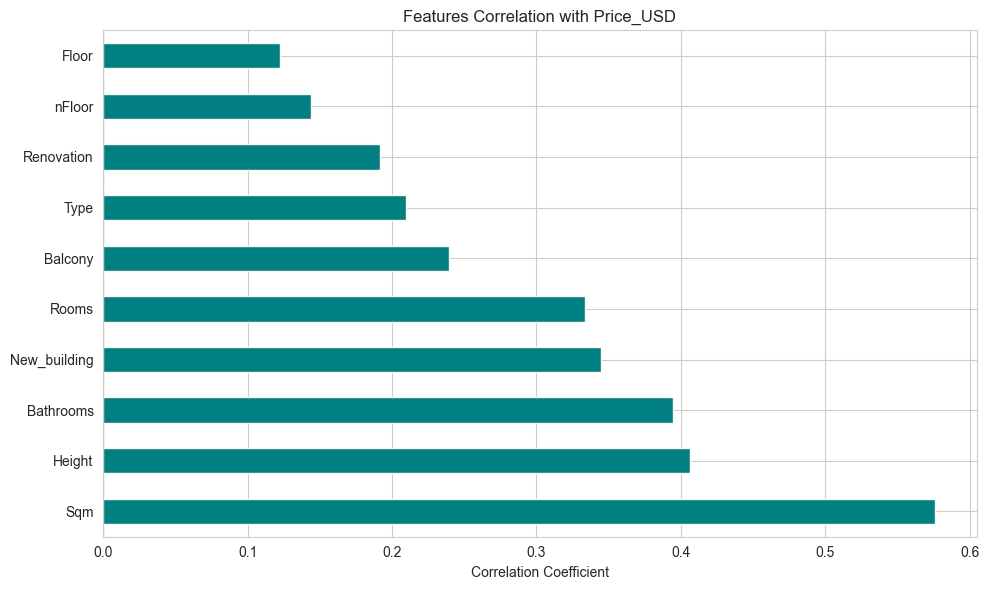

In [59]:
# Correlation with Price (sorted)
price_corr = data.corr()['Price_USD'].sort_values(ascending=False)
print("Correlation with Price_USD:\n")
print(price_corr)

# Visualize
plt.figure(figsize=(10, 6))
price_corr.drop('Price_USD').plot(kind='barh', color='teal')
plt.xlabel('Correlation Coefficient')
plt.title('Features Correlation with Price_USD')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

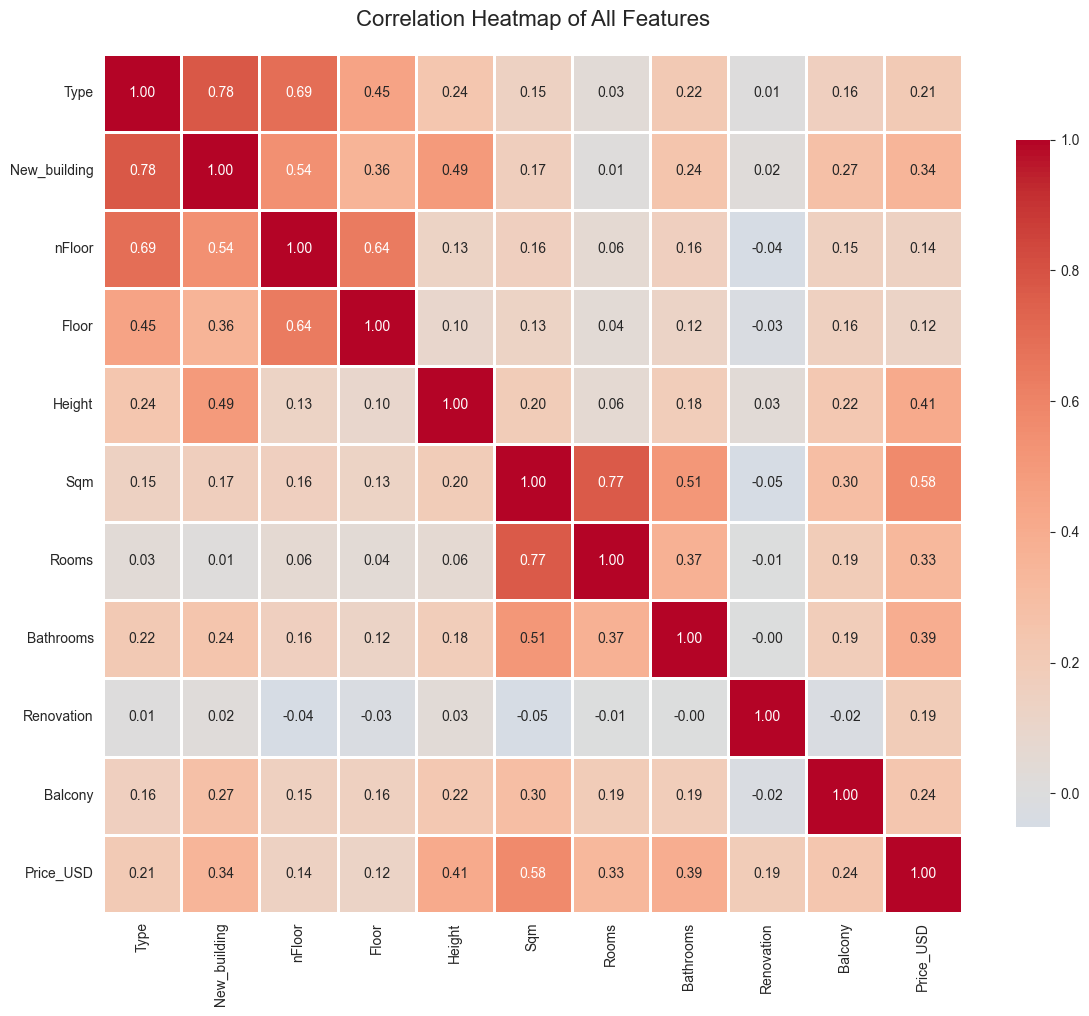

In [60]:
# Correlation matrix
correlation_matrix = data.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of All Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 8. Relationship Between Features and Price

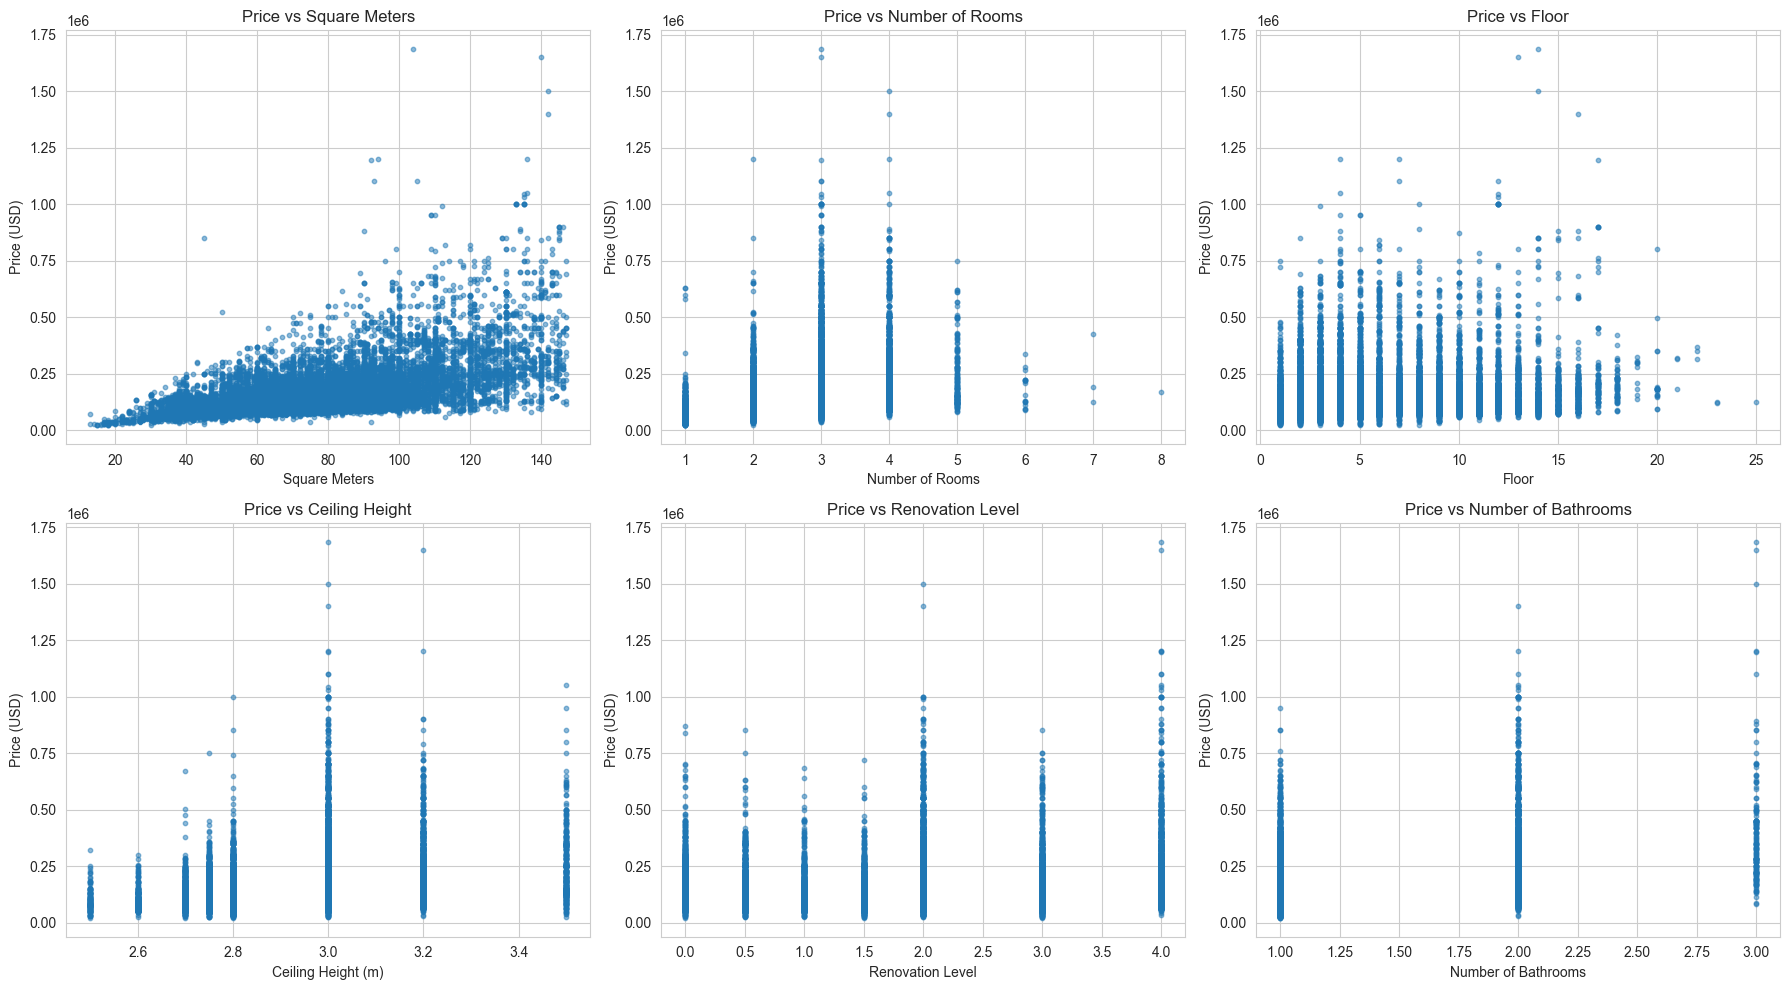

In [61]:
# Scatter plots: Key features vs Price
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sqm vs Price
axes[0, 0].scatter(data['Sqm'], data['Price_USD'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Square Meters')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].set_title('Price vs Square Meters')

# Rooms vs Price
axes[0, 1].scatter(data['Rooms'], data['Price_USD'], alpha=0.5, s=10)
axes[0, 1].set_xlabel('Number of Rooms')
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_title('Price vs Number of Rooms')

# Floor vs Price
axes[0, 2].scatter(data['Floor'], data['Price_USD'], alpha=0.5, s=10)
axes[0, 2].set_xlabel('Floor')
axes[0, 2].set_ylabel('Price (USD)')
axes[0, 2].set_title('Price vs Floor')

# Height vs Price
axes[1, 0].scatter(data['Height'], data['Price_USD'], alpha=0.5, s=10)
axes[1, 0].set_xlabel('Ceiling Height (m)')
axes[1, 0].set_ylabel('Price (USD)')
axes[1, 0].set_title('Price vs Ceiling Height')

# Renovation vs Price
axes[1, 1].scatter(data['Renovation'], data['Price_USD'], alpha=0.5, s=10)
axes[1, 1].set_xlabel('Renovation Level')
axes[1, 1].set_ylabel('Price (USD)')
axes[1, 1].set_title('Price vs Renovation Level')

# Bathrooms vs Price
axes[1, 2].scatter(data['Bathrooms'], data['Price_USD'], alpha=0.5, s=10)
axes[1, 2].set_xlabel('Number of Bathrooms')
axes[1, 2].set_ylabel('Price (USD)')
axes[1, 2].set_title('Price vs Number of Bathrooms')

plt.tight_layout()
plt.show()

## 9. Price Analysis by Categories

In [62]:
# Average price by categories
print("Average Price by Property Type:")
print(data.groupby('Type')['Price_USD'].mean().sort_values(ascending=False))
print("\n" + "="*50 + "\n")

print("Average Price by Building Type:")
print(data.groupby('New_building')['Price_USD'].mean())
print("\n" + "="*50 + "\n")

print("Average Price by Number of Rooms:")
print(data.groupby('Rooms')['Price_USD'].mean().sort_index())
print("\n" + "="*50 + "\n")

print("Average Price by Number of Bathrooms:")
print(data.groupby('Bathrooms')['Price_USD'].mean().sort_index())

Average Price by Property Type:
Type
2    207791.877031
0    155402.396689
1    116713.448908
3    106215.342857
Name: Price_USD, dtype: float64


Average Price by Building Type:
New_building
0    134587.748728
1    209746.364696
Name: Price_USD, dtype: float64


Average Price by Number of Rooms:
Rooms
1     81660.446931
2    128322.369938
3    180019.723384
4    205249.753954
5    235623.306358
6    179912.000000
7    246333.333333
8    170000.000000
Name: Price_USD, dtype: float64


Average Price by Number of Bathrooms:
Bathrooms
1    139093.402204
2    224429.169832
3    384711.779570
Name: Price_USD, dtype: float64


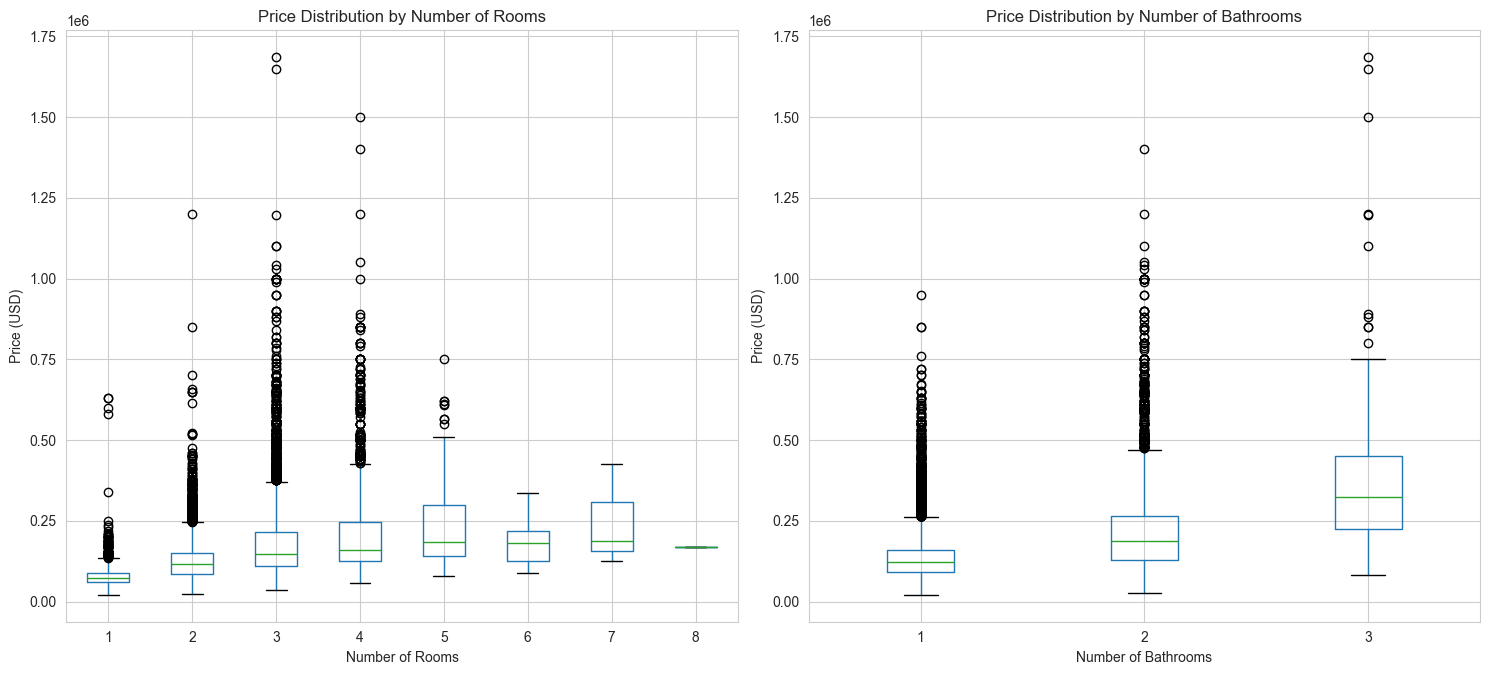

In [70]:
# Box plots: Price by categorical features
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Price by Number of Rooms
data.boxplot(column='Price_USD', by='Rooms', ax=axes[0])
axes[0].set_xlabel('Number of Rooms')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Price Distribution by Number of Rooms')

# Price by Number of Bathrooms
data.boxplot(column='Price_USD', by='Bathrooms', ax=axes[1])
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('Price Distribution by Number of Bathrooms')

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()


Price by Floor Position:
                         mean    median  count
Floor_Position                                
Ground          116213.352747  102000.0   1820
Middle          168205.569465  137000.0  15641
Top             147118.342891  120000.0   3418


<Figure size 1000x600 with 0 Axes>

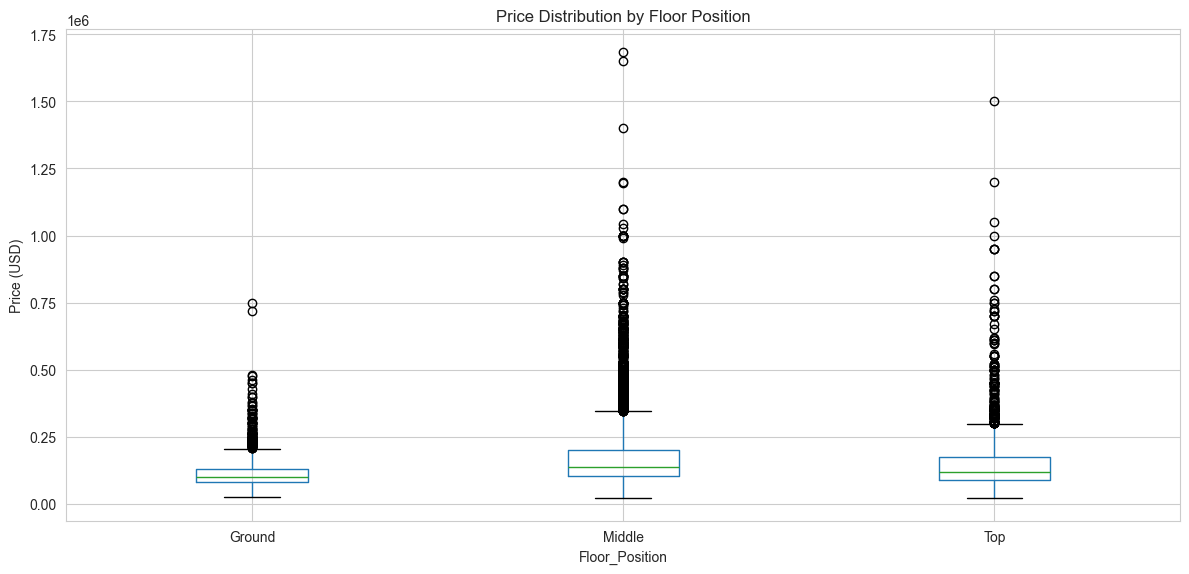

In [80]:
# Floor position analysis (bottom, middle, top)
def categorize_floor(row):
    if row['Floor'] == 1:
        return 'Ground'
    elif row['Floor'] == row['nFloor']:
        return 'Top'
    else:
        return 'Middle'

data['Floor_Position'] = data.apply(categorize_floor, axis=1)

# Average price by floor position
floor_position_price = data.groupby('Floor_Position')['Price_USD'].agg(['mean', 'median', 'count'])
print("\nPrice by Floor Position:")
print(floor_position_price)

plt.figure(figsize=(10, 6))
data.boxplot(column='Price_USD', by='Floor_Position')
plt.ylabel('Price (USD)')
plt.title('Price Distribution by Floor Position')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 10. Outlier Detection

In [71]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check for outliers in key numerical columns
numerical_cols = ['Sqm', 'Price_USD', 'Floor', 'nFloor', 'Height']

print("Outlier Analysis:\n")
for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(data, col)
    print(f"{col}:")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"  Range: [{lower:.2f}, {upper:.2f}]")
    print()

Outlier Analysis:

Sqm:
  Number of outliers: 147 (0.70%)
  Range: [9.50, 141.50]

Price_USD:
  Number of outliers: 1290 (6.18%)
  Range: [-39500.00, 324500.00]

Floor:
  Number of outliers: 427 (2.05%)
  Range: [-4.50, 15.50]

nFloor:
  Number of outliers: 0 (0.00%)
  Range: [-8.50, 27.50]

Height:
  Number of outliers: 388 (1.86%)
  Range: [2.38, 3.38]



## 11. Feature Engineering Insights

Price per Square Meter Statistics:
Mean: $2,097.27/sqm
Median: $1,838.24/sqm
Min: $380.43/sqm
Max: $18,888.89/sqm


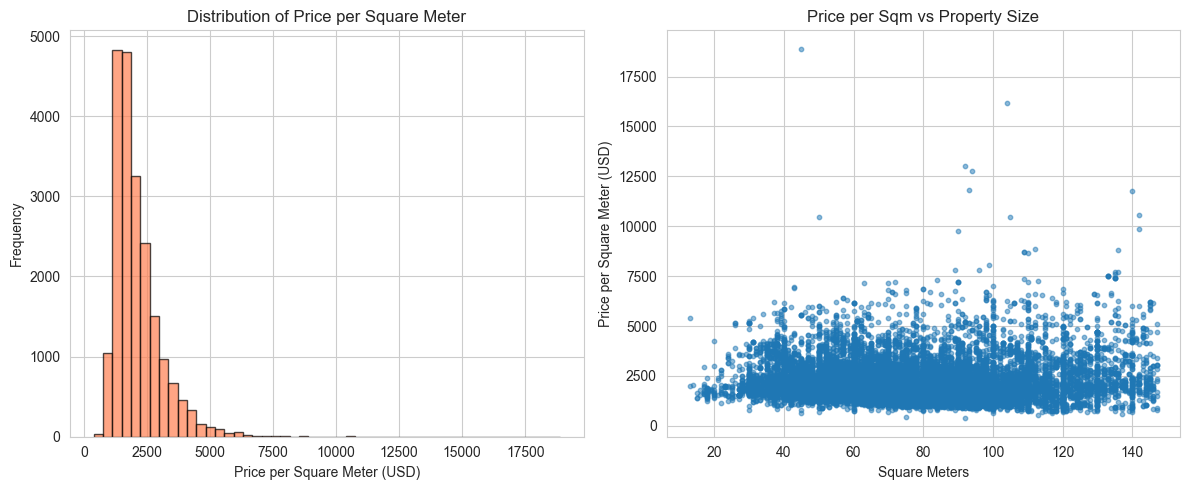

In [74]:
# Calculate price per square meter
price_per_Sqm = data['Price_USD'] / data['Sqm']

print("Price per Square Meter Statistics:")
print(f"Mean: ${price_per_Sqm.mean():,.2f}/sqm")
print(f"Median: ${price_per_Sqm.median():,.2f}/sqm")
print(f"Min: ${price_per_Sqm.min():,.2f}/sqm")
print(f"Max: ${price_per_Sqm.max():,.2f}/sqm")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(price_per_Sqm, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Price per Square Meter (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Price per Square Meter')

plt.subplot(1, 2, 2)
plt.scatter(data['Sqm'], price_per_Sqm, alpha=0.5, s=10)
plt.xlabel('Square Meters')
plt.ylabel('Price per Square Meter (USD)')
plt.title('Price per Sqm vs Property Size')

plt.tight_layout()
plt.show()

## 12. Key Insights Summary

In [78]:
# Summary of key insights
print("="*60)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*60)
print(f"\n1. Dataset Size: {data.shape[0]:,} properties with {data.shape[1]} features")
print(f"\n2. Price Range: ${data['Price_USD'].min():,.0f} - ${data['Price_USD'].max():,.0f}")
print(f"   Average Price: ${data['Price_USD'].mean():,.0f}")
print(f"   Median Price: ${data['Price_USD'].median():,.0f}")

print(f"\n3. Property Size Range: {data['Sqm'].min():.0f} - {data['Sqm'].max():.0f} sqm")
print(f"   Average Size: {data['Sqm'].mean():.1f} sqm")

print(f"\n4. Most Common Property Type: {data['Type'].mode()[0]}")
print(f"   Most Common Room Count: {data['Rooms'].mode()[0]} rooms")

print("\n5. Top 3 Features Correlated with Price:")
price_corr_sorted = data.corr()['Price_USD'].abs().sort_values(ascending=False)
for i, (feature, corr) in enumerate(price_corr_sorted[1:4].items(), 1):
    print(f"   {i}. {feature}: {corr:.3f}")

print("\n6. New Buildings vs Old Buildings:")
print(f"   New: {(data['New_building']==1).sum():,} ({(data['New_building']==1).sum()/len(data)*100:.1f}%)")
print(f"   Old: {(data['New_building']==0).sum():,} ({(data['New_building']==0).sum()/len(data)*100:.1f}%)")

print("\n" + "="*60)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. Dataset Size: 20,879 properties with 11 features

2. Price Range: $21,000 - $1,685,000
   Average Price: $160,221
   Median Price: $130,000

3. Property Size Range: 13 - 147 sqm
   Average Size: 76.1 sqm

4. Most Common Property Type: 2
   Most Common Room Count: 3 rooms

5. Top 3 Features Correlated with Price:
   1. Sqm: 0.576
   2. Height: 0.406
   3. Bathrooms: 0.395

6. New Buildings vs Old Buildings:
   New: 7,121 (34.1%)
   Old: 13,758 (65.9%)

